In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/jovyan/work/Plant_1_Generation_Data.csv')

In [3]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
df.shape

(68778, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [8]:
(df["DC_POWER"] == 0).sum()

31951

In [9]:
(df["DC_POWER"] == 0).mean() * 100

46.455261856989154

In [10]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], format="%d-%m-%Y %H:%M")

In [11]:
df["DATE_TIME"].head()

0   2020-05-15
1   2020-05-15
2   2020-05-15
3   2020-05-15
4   2020-05-15
Name: DATE_TIME, dtype: datetime64[ns]

In [12]:
df["DATE_TIME"].iloc[2]

Timestamp('2020-05-15 00:00:00')

In [13]:
df["HOUR"] = df["DATE_TIME"].dt.hour

In [14]:
df[["DATE_TIME", "HOUR"]].head()

,DATE_TIME,HOUR
0,2020-05-15,0
1,2020-05-15,0
2,2020-05-15,0
3,2020-05-15,0
4,2020-05-15,0


In [15]:
df.groupby("HOUR")["DC_POWER"].mean()

HOUR
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.000000
6      578.113622
7     2551.386720
8     5088.628218
9     7247.398958
10    8720.411543
11    9805.565924
12    9731.281831
13    9232.377553
14    7977.016268
15    6457.881863
16    4082.438281
17    1756.366881
18     228.867923
19       0.000000
20       0.000000
21       0.000000
22       0.000000
23       0.000000
Name: DC_POWER, dtype: float64

In [16]:
night_zero = df[(df["HOUR"].isin([19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5])) & (df["DC_POWER"] == 0)]
night_zero.shape[0]

30847

In [17]:
night_zero.shape[0] / (df["DC_POWER"] == 0).sum() * 100

96.54470908578762

In [18]:
day_zero = df[(~df["HOUR"].isin([19, 20, 21, 22, 23, 0, 1, 2, 3, 4, 5])) & (df["DC_POWER"] == 0)]
day_zero.shape[0]

1104

In [19]:
day_zero["SOURCE_KEY"].value_counts().head(10)

bvBOhCH3iADSZry    77
1BY6WEcLGh8j5v7    74
z9Y9gH1T5YWrNuG    53
VHMLBKoKgIrUVDU    52
7JYdWkrLSPkdwr4    51
ZnxXDlPa8U1GXgE    50
zBIq5rxdHJRwDNY    50
wCURE6d3bPkepu2    49
sjndEbLyjtCKgGv    49
iCRJl6heRkivqQ3    48
Name: SOURCE_KEY, dtype: int64

In [20]:
total_by_source = df["SOURCE_KEY"].value_counts()

In [21]:
day_zero_by_source = day_zero["SOURCE_KEY"].value_counts()

In [22]:
day_zero_rate = (day_zero_by_source / total_by_source * 100).sort_values(ascending = True)

In [23]:
day_zero_rate.head(10)

adLQvlD726eNBSB    1.314524
rGa61gmuvPhdLxV    1.408451
ZoEaEvLYb1n2sOq    1.440922
1IF53ai7Xc0U56Y    1.442770
pkci93gMrogZuBj    1.472000
YxYtjZvoooNbGkE    1.481959
uHbuxQJl8lW7ozc    1.504000
McdE0feGgRqW7Ca    1.504481
3PZuoBAID5Wc2HD    1.507377
WRmjgnKYAwPKWDb    1.507377
Name: SOURCE_KEY, dtype: float64

In [24]:
day_zero["DATE_TIME"].dt.date.value_counts().head(10)

2020-05-19    92
2020-05-17    64
2020-06-07    55
2020-05-15    47
2020-06-14    46
2020-05-26    45
2020-06-11    44
2020-05-18    44
2020-06-12    44
2020-05-16    44
Name: DATE_TIME, dtype: int64

In [25]:
day_zero[day_zero["DATE_TIME"].dt.date == pd.to_datetime("2020-05-19").date()]["HOUR"].value_counts().sort_index()

6     22
18    70
Name: HOUR, dtype: int64

In [26]:
(day_zero["AC_POWER"] == 0).sum()

1104

In [27]:
df_power = df[df["DC_POWER"]> 0].copy()

In [28]:
df_power["EFFICIENCY"] = df_power["AC_POWER"] / df_power["DC_POWER"]

In [29]:
df_power["EFFICIENCY"].describe()

count    36827.000000
mean         0.097719
std          0.000458
min          0.095552
25%          0.097579
50%          0.097845
75%          0.098014
max          0.106592
Name: EFFICIENCY, dtype: float64

In [30]:
df_power.rename(columns = {"EFFICIENCY": "AC_DC_RATIO"}, inplace = True)

In [31]:
df_power.groupby("HOUR")["AC_DC_RATIO"].mean()

HOUR
6     0.096870
7     0.098005
8     0.098067
9     0.097901
10    0.097782
11    0.097706
12    0.097717
13    0.097745
14    0.097828
15    0.097933
16    0.098054
17    0.097611
18    0.096651
Name: AC_DC_RATIO, dtype: float64

In [32]:
hourly_power = df.groupby("HOUR")["DC_POWER"].mean()

In [33]:
hourly_power

HOUR
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.000000
6      578.113622
7     2551.386720
8     5088.628218
9     7247.398958
10    8720.411543
11    9805.565924
12    9731.281831
13    9232.377553
14    7977.016268
15    6457.881863
16    4082.438281
17    1756.366881
18     228.867923
19       0.000000
20       0.000000
21       0.000000
22       0.000000
23       0.000000
Name: DC_POWER, dtype: float64

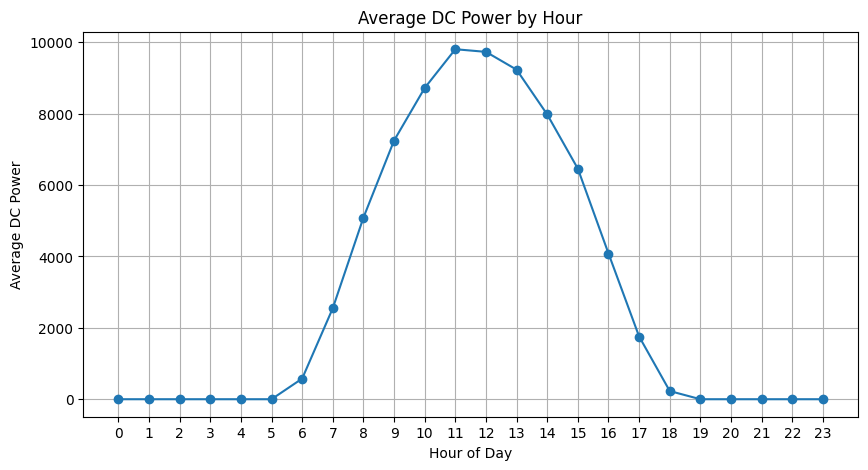

In [34]:
plt.figure(figsize = (10, 5))
plt.plot(hourly_power.index, hourly_power.values, marker = "o")
plt.title("Average DC Power by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average DC Power")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [35]:
hourly_power.idxmax()

11

In [36]:
hourly_power.max()

9805.565923510796

In [37]:
df["DATE"] = df["DATE_TIME"].dt.date

In [38]:
daily_power = df.groupby("DATE")["DC_POWER"].mean()

In [39]:
daily_power.idxmax()

datetime.date(2020, 5, 21)

In [40]:
daily_power.max()

4956.921158773319

In [41]:
best_day = df[df["DATE"] == pd.to_datetime("2020-05-21").date()]

In [42]:
best_day_hourly = best_day.groupby("HOUR")["DC_POWER"].mean()

In [43]:
best_day_hourly

HOUR
7      3468.084091
8      5994.537676
9      9190.750609
10     8343.435484
11    11879.352069
12     9952.323458
13    11102.356155
14     8402.908076
15     6981.618845
16     3533.155438
17      712.393263
18      130.320617
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: DC_POWER, dtype: float64

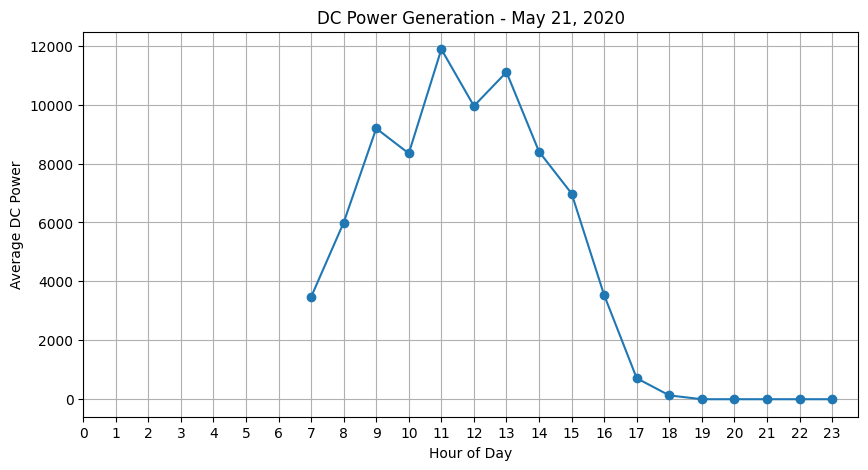

In [44]:
plt.figure(figsize = (10, 5))
plt.plot(best_day_hourly.index, best_day_hourly.values, marker = "o")
plt.title("DC Power Generation - May 21, 2020")
plt.xlabel("Hour of Day")
plt.ylabel("Average DC Power")
plt.xticks(range(24))
plt.grid(True)
plt.show()

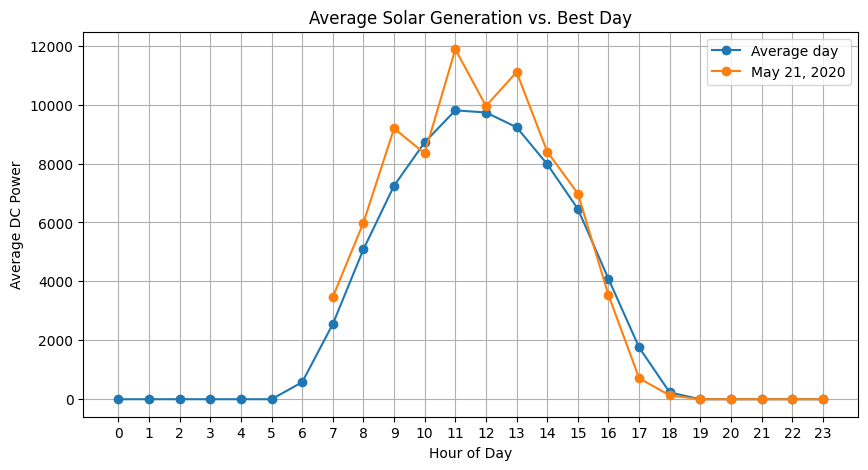

In [45]:
plt.figure(figsize = (10, 5))
plt.plot(hourly_power.index, hourly_power.values, marker = "o", label = "Average day")

plt.plot(best_day_hourly.index, best_day_hourly.values, marker = "o", label = "May 21, 2020")

plt.title("Average Solar Generation vs. Best Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average DC Power")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

In [46]:
average_daily_power = daily_power.mean()

In [47]:
average_daily_power

3183.0917174291803

In [48]:
((daily_power.max() - average_daily_power) / average_daily_power) * 100

55.72662049388792

In [49]:
daily_power.idxmin()

datetime.date(2020, 5, 18)

In [50]:
daily_power.min()

2278.668814254926

In [51]:
(daily_power.max() / daily_power.min())

2.1753583178756593

In [52]:
((daily_power.max() - daily_power.min()) / daily_power.min()) * 100

117.53583178756593

In [53]:
worst_day = df[df["DATE"] == pd.to_datetime("2020-05-18").date()]

In [54]:
worst_day_hourly = worst_day.groupby("HOUR")["DC_POWER"].mean()

In [55]:
worst_day_hourly

HOUR
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6       587.004870
7      2394.014407
8      1599.330560
9      1627.986810
10     3202.990463
11     6232.456372
12     8298.032873
13    10520.341112
14     6869.028003
15     7575.712662
16     4192.146104
17     1441.020495
18      147.986810
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: DC_POWER, dtype: float64

In [56]:
print(best_day_hourly)
print(worst_day_hourly)

HOUR
7      3468.084091
8      5994.537676
9      9190.750609
10     8343.435484
11    11879.352069
12     9952.323458
13    11102.356155
14     8402.908076
15     6981.618845
16     3533.155438
17      712.393263
18      130.320617
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: DC_POWER, dtype: float64
HOUR
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6       587.004870
7      2394.014407
8      1599.330560
9      1627.986810
10     3202.990463
11     6232.456372
12     8298.032873
13    10520.341112
14     6869.028003
15     7575.712662
16     4192.146104
17     1441.020495
18      147.986810
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: DC_POWER, dtype: float64


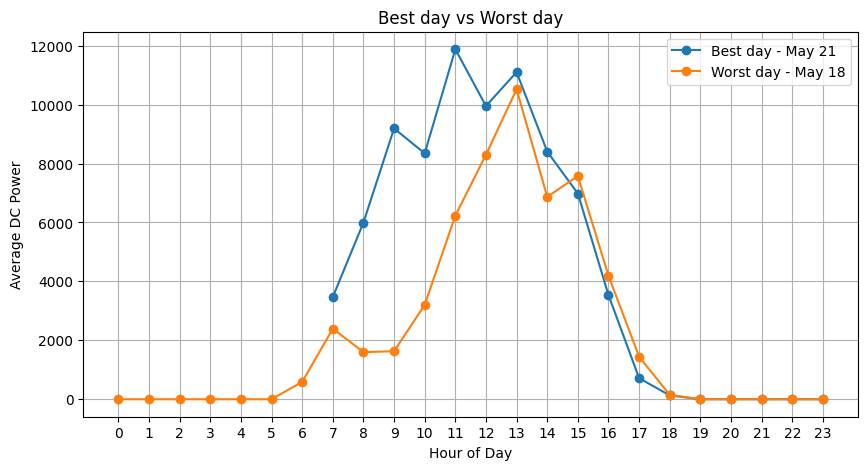

In [57]:
plt.figure(figsize = (10, 5))
plt.plot(best_day_hourly.index, best_day_hourly.values, marker = "o", label = "Best day - May 21")
           
plt.plot(worst_day_hourly.index, worst_day_hourly.values, marker = "o", label = "Worst day - May 18")

plt.title("Best day vs Worst day")
plt.xlabel("Hour of Day")
plt.ylabel("Average DC Power")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()


In [58]:
comparison = pd.DataFrame({"BEST_DAY": best_day_hourly, "WORST_DAY": worst_day_hourly})

In [59]:
comparison["DIFFERENCE"] = comparison["BEST_DAY"] - comparison["WORST_DAY"]

In [60]:
comparison["DIFFERENCE"].idxmax()

9

In [61]:
comparison["DIFFERENCE"].max()

7562.763798659092

In [62]:
source_power = df.groupby("SOURCE_KEY")["DC_POWER"].mean().sort_values(ascending = False)

In [63]:
source_power.head(10)

SOURCE_KEY
adLQvlD726eNBSB    3269.567669
1IF53ai7Xc0U56Y    3226.336768
3PZuoBAID5Wc2HD    3221.015673
McdE0feGgRqW7Ca    3211.307245
VHMLBKoKgIrUVDU    3210.102563
iCRJl6heRkivqQ3    3196.074675
uHbuxQJl8lW7ozc    3195.316080
ZnxXDlPa8U1GXgE    3194.059104
zVJPv84UY57bAof    3187.236622
YxYtjZvoooNbGkE    3179.492570
Name: DC_POWER, dtype: float64

In [64]:
source_power.tail(10)

SOURCE_KEY
rGa61gmuvPhdLxV    3163.240929
WRmjgnKYAwPKWDb    3155.384433
zBIq5rxdHJRwDNY    3148.590013
sjndEbLyjtCKgGv    3148.270450
ZoEaEvLYb1n2sOq    3139.009808
z9Y9gH1T5YWrNuG    3134.037738
7JYdWkrLSPkdwr4    3132.891955
ih0vzX44oOqAx2f    3097.714161
1BY6WEcLGh8j5v7    2873.720981
bvBOhCH3iADSZry    2828.998291
Name: DC_POWER, dtype: float64

In [65]:
source_power = df["SOURCE_KEY"].value_counts()

In [66]:
source_power.head(10)

bvBOhCH3iADSZry    3155
1BY6WEcLGh8j5v7    3154
7JYdWkrLSPkdwr4    3133
VHMLBKoKgIrUVDU    3133
ih0vzX44oOqAx2f    3130
ZnxXDlPa8U1GXgE    3130
wCURE6d3bPkepu2    3126
z9Y9gH1T5YWrNuG    3126
iCRJl6heRkivqQ3    3125
pkci93gMrogZuBj    3125
Name: SOURCE_KEY, dtype: int64

In [67]:
source_power.tail(10)

McdE0feGgRqW7Ca    3124
sjndEbLyjtCKgGv    3124
zVJPv84UY57bAof    3124
ZoEaEvLYb1n2sOq    3123
1IF53ai7Xc0U56Y    3119
adLQvlD726eNBSB    3119
zBIq5rxdHJRwDNY    3119
WRmjgnKYAwPKWDb    3118
3PZuoBAID5Wc2HD    3118
YxYtjZvoooNbGkE    3104
Name: SOURCE_KEY, dtype: int64

In [68]:
source_max = source_power.max()
source_min = source_power.min()

print("Máximo:", source_max)
print("Mínimo:", source_min)
print("Diferencia:", source_max - source_min)
print("Diferencia %:", ((source_max - source_min) / source_min)* 100)

Máximo: 3155
Mínimo: 3104
Diferencia: 51
Diferencia %: 1.6430412371134022


In [69]:
source_power = df.groupby("SOURCE_KEY")["DC_POWER"].mean().sort_values(ascending = False)

In [70]:
source_power.head(10)

SOURCE_KEY
adLQvlD726eNBSB    3269.567669
1IF53ai7Xc0U56Y    3226.336768
3PZuoBAID5Wc2HD    3221.015673
McdE0feGgRqW7Ca    3211.307245
VHMLBKoKgIrUVDU    3210.102563
iCRJl6heRkivqQ3    3196.074675
uHbuxQJl8lW7ozc    3195.316080
ZnxXDlPa8U1GXgE    3194.059104
zVJPv84UY57bAof    3187.236622
YxYtjZvoooNbGkE    3179.492570
Name: DC_POWER, dtype: float64

In [71]:
source_max = source_power.max()
source_min = source_power.min()

print("Máximo:", source_max)
print("Mínimo:", source_min)
print("Diferencia:", source_max - source_min)
print("Diferencia %:", ((source_max - source_min)/ source_min) * 100)

Máximo: 3269.5676689912134
Mínimo: 2828.9982906993628
Diferencia: 440.5693782918506
Diferencia %: 15.573334905866504


In [72]:
print("Mayor:", source_power.idxmax())
print("Menor:", source_power.idxmin())

Mayor: adLQvlD726eNBSB
Menor: bvBOhCH3iADSZry


In [73]:
top_inverter = df[df["SOURCE_KEY"] == "adLQvlD726eNBSB"]

In [74]:
bottom_inverter = df[df["SOURCE_KEY"] == "bvBOhCH3iADSZry"]

In [75]:
top_hourly = top_inverter.groupby("HOUR")["DC_POWER"].mean()

In [76]:
bottom_hourly = bottom_inverter.groupby("HOUR")["DC_POWER"].mean()

In [77]:
top_hourly

HOUR
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6       627.733418
7      2745.864393
8      5381.591833
9      7575.767638
10     9111.626576
11    10127.580820
12    10088.040059
13     9610.082711
14     8231.139881
15     6541.183847
16     4121.889011
17     1765.840110
18      239.853619
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: DC_POWER, dtype: float64

In [78]:
bottom_hourly

HOUR
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.000000
6      536.175971
7     2370.491568
8     4718.815695
9     6647.334471
10    8108.199317
11    8970.833466
12    8549.889215
13    8120.956024
14    7029.091876
15    5964.288285
16    3773.049648
17    1619.677727
18     195.209296
19       0.000000
20       0.000000
21       0.000000
22       0.000000
23       0.000000
Name: DC_POWER, dtype: float64

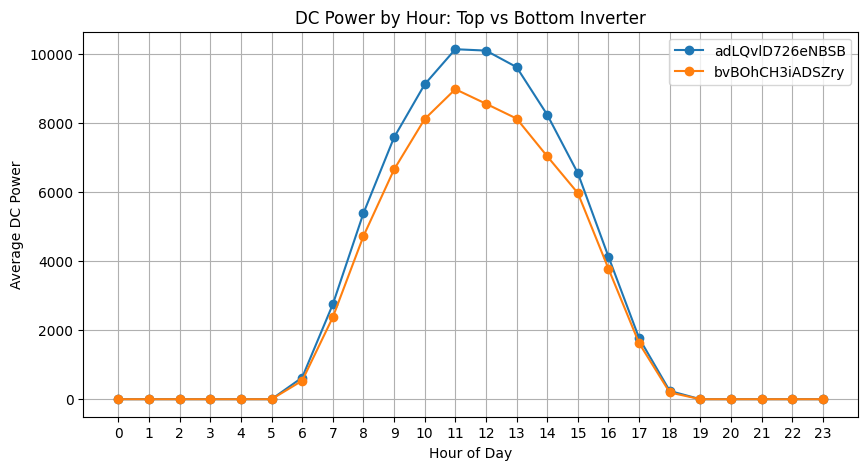

In [79]:
plt.figure(figsize = (10, 5))
plt.plot(top_hourly.index, top_hourly.values, marker = "o", label = "adLQvlD726eNBSB")
plt.plot(bottom_hourly.index, bottom_hourly.values, marker = "o", label = "bvBOhCH3iADSZry")
plt.title("DC Power by Hour: Top vs Bottom Inverter")
plt.xlabel("Hour of Day")
plt.ylabel("Average DC Power")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

In [80]:
zero_power_by_source = (df[df["DC_POWER"] == 0].groupby("SOURCE_KEY").size().sort_values(ascending = True))

In [81]:
zero_power_by_source.head(10)

SOURCE_KEY
YxYtjZvoooNbGkE    1429
adLQvlD726eNBSB    1441
1IF53ai7Xc0U56Y    1445
rGa61gmuvPhdLxV    1445
zBIq5rxdHJRwDNY    1445
ZoEaEvLYb1n2sOq    1446
3PZuoBAID5Wc2HD    1447
WRmjgnKYAwPKWDb    1447
pkci93gMrogZuBj    1447
uHbuxQJl8lW7ozc    1448
dtype: int64

In [82]:
source_count = df["SOURCE_KEY"].value_counts()

In [83]:
zero_percentage = (zero_power_by_source / source_count) * 100

In [84]:
zero_percentage.sort_values(ascending = False).head(10)

bvBOhCH3iADSZry    47.480190
1BY6WEcLGh8j5v7    47.400127
z9Y9gH1T5YWrNuG    46.545106
VHMLBKoKgIrUVDU    46.473029
ZnxXDlPa8U1GXgE    46.453674
7JYdWkrLSPkdwr4    46.441111
wCURE6d3bPkepu2    46.417147
sjndEbLyjtCKgGv    46.414853
3PZuoBAID5Wc2HD    46.407954
WRmjgnKYAwPKWDb    46.407954
dtype: float64

In [85]:
print("Mayor DC_POWER:", zero_percentage["adLQvlD726eNBSB"])
print("Menor DC_POWER:", zero_percentage["bvBOhCH3iADSZry"])

Mayor DC_POWER: 46.20070535428022
Menor DC_POWER: 47.48019017432647


In [86]:
bottom_zero_by_hour = (bottom_inverter[bottom_inverter["DC_POWER"] == 0].groupby("HOUR").size())

In [87]:
bottom_zero_by_hour

HOUR
0     124
1     124
2     128
3     128
4     128
5     123
6       7
11      3
12      7
13      7
14      3
18     50
19    136
20    136
21    135
22    134
23    125
dtype: int64

In [88]:
top_zero_by_hour = (top_inverter[top_inverter["DC_POWER"] == 0].groupby("HOUR").size())

In [89]:
top_zero_by_hour

HOUR
0     124
1     124
2     127
3     128
4     128
5     124
6       4
18     37
19    121
20    131
21    134
22    134
23    125
dtype: int64

In [90]:
daytime = df[(df["HOUR"] >= 6) & (df["HOUR"] <= 18)]

In [91]:
daytime_zero_by_source = (daytime[daytime["DC_POWER"] == 0].groupby("SOURCE_KEY").size().sort_values(ascending = False))

In [92]:
daytime_zero_by_source.head(10)

SOURCE_KEY
bvBOhCH3iADSZry    77
1BY6WEcLGh8j5v7    74
z9Y9gH1T5YWrNuG    53
VHMLBKoKgIrUVDU    52
7JYdWkrLSPkdwr4    51
zBIq5rxdHJRwDNY    50
ZnxXDlPa8U1GXgE    50
wCURE6d3bPkepu2    49
sjndEbLyjtCKgGv    49
iCRJl6heRkivqQ3    48
dtype: int64

In [93]:
daytime_count_by_source = daytime.groupby("SOURCE_KEY").size()

In [94]:
daytime_zero_percentage = (daytime_zero_by_source / daytime_count_by_source) * 100

In [95]:
daytime_zero_percentage.sort_values(ascending = False).head(10)

SOURCE_KEY
bvBOhCH3iADSZry    4.440600
1BY6WEcLGh8j5v7    4.270052
z9Y9gH1T5YWrNuG    3.074246
VHMLBKoKgIrUVDU    3.007519
7JYdWkrLSPkdwr4    2.949682
zBIq5rxdHJRwDNY    2.900232
ZnxXDlPa8U1GXgE    2.896871
sjndEbLyjtCKgGv    2.843877
wCURE6d3bPkepu2    2.842227
zVJPv84UY57bAof    2.785839
dtype: float64

In [96]:
bottom_daytime_zero = (daytime[(daytime["SOURCE_KEY"] == "bvBOhCH3iADSZry") & (daytime["DC_POWER"] == 0)].groupby("DATE").size().sort_values(ascending = False))

In [97]:
bottom_daytime_zero.head(10)

DATE
2020-06-14    13
2020-06-07     9
2020-05-19     5
2020-06-17     3
2020-05-17     3
2020-05-18     3
2020-05-26     3
2020-05-29     2
2020-06-16     2
2020-06-12     2
dtype: int64

In [98]:
bottom_daytime_zero = (
    daytime[
        (daytime["SOURCE_KEY"] == "bvBOhCH3iADSZry") &
        (daytime["DC_POWER"] == 0)
    ]
    .groupby("DATE")
    .size()
    .sort_values(ascending=False)
)

In [99]:
bottom_daytime_zero.head(10)

DATE
2020-06-14    13
2020-06-07     9
2020-05-19     5
2020-06-17     3
2020-05-17     3
2020-05-18     3
2020-05-26     3
2020-05-29     2
2020-06-16     2
2020-06-12     2
dtype: int64

In [100]:
daytime.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD', 'HOUR', 'DATE'],
      dtype='object')

In [101]:
print(daytime["DATE"].dtype)
print(daytime["DATE"].unique()[:10])

object
[datetime.date(2020, 5, 15) datetime.date(2020, 5, 16)
 datetime.date(2020, 5, 17) datetime.date(2020, 5, 18)
 datetime.date(2020, 5, 19) datetime.date(2020, 5, 20)
 datetime.date(2020, 5, 21) datetime.date(2020, 5, 22)
 datetime.date(2020, 5, 23) datetime.date(2020, 5, 24)]


In [102]:
bottom_anomaly_hours = (daytime[(daytime["SOURCE_KEY"] == "bvBOhCH3iADSZry") & (daytime["DATE"] == pd.to_datetime(2020-6-14).date()) & (daytime["DC_POWER"] == 0)][["DATE_TIME", "HOUR", "DC_POWER", "AC_POWER"]])
bottom_anomaly_hours

,DATE_TIME,HOUR,DC_POWER,AC_POWER


In [103]:
day_14 = daytime[(daytime["SOURCE_KEY"] == "bvBOhCH3iADSZry") & (daytime["DATE"] == pd.to_datetime("2020-06-14").date())]
day_14[["DATE_TIME", "HOUR", "DC_POWER", "AC_POWER"]]

,DATE_TIME,HOUR,DC_POWER,AC_POWER
60913,2020-06-14 06:00:00,6,50.285714,4.857143
60935,2020-06-14 06:15:00,6,301.875000,29.162500
60957,2020-06-14 06:30:00,6,620.571429,60.085714
60979,2020-06-14 06:45:00,6,1018.500000,98.950000
61001,2020-06-14 07:00:00,7,1793.000000,175.557143
61023,2020-06-14 07:15:00,7,2896.142857,284.242857
61045,2020-06-14 07:30:00,7,2988.500000,293.425000
61067,2020-06-14 07:45:00,7,3859.714286,379.228571
61089,2020-06-14 08:00:00,8,3832.500000,376.625000
61111,2020-06-14 08:15:00,8,3132.857143,307.500000


In [104]:
day_14[(day_14["DC_POWER"] == 0)][["DATE_TIME", "HOUR", "DC_POWER", "AC_POWER"]]

,DATE_TIME,HOUR,DC_POWER,AC_POWER
61375,2020-06-14 11:15:00,11,0.0,0.0
61397,2020-06-14 11:30:00,11,0.0,0.0
61419,2020-06-14 11:45:00,11,0.0,0.0
61441,2020-06-14 12:00:00,12,0.0,0.0
61463,2020-06-14 12:15:00,12,0.0,0.0
61485,2020-06-14 12:30:00,12,0.0,0.0
61507,2020-06-14 12:45:00,12,0.0,0.0
61529,2020-06-14 13:00:00,13,0.0,0.0
61551,2020-06-14 13:15:00,13,0.0,0.0
61573,2020-06-14 13:30:00,13,0.0,0.0


In [105]:
day_14_period = daytime[(daytime["DATE"] == pd.to_datetime("2020-06-14").date()) & (daytime["DATE_TIME"] >= "2020-06-14 11:15:00") & (daytime["DATE_TIME"] <= "2020-06-14 14:00:00")]
day_14_period.groupby("SOURCE_KEY")["DC_POWER"].apply(lambda x: (x == 0).sum()).sort_values(ascending = False)

SOURCE_KEY
1BY6WEcLGh8j5v7    12
bvBOhCH3iADSZry    12
3PZuoBAID5Wc2HD     0
7JYdWkrLSPkdwr4     0
zBIq5rxdHJRwDNY     0
z9Y9gH1T5YWrNuG     0
wCURE6d3bPkepu2     0
uHbuxQJl8lW7ozc     0
sjndEbLyjtCKgGv     0
rGa61gmuvPhdLxV     0
pkci93gMrogZuBj     0
ih0vzX44oOqAx2f     0
iCRJl6heRkivqQ3     0
1IF53ai7Xc0U56Y     0
adLQvlD726eNBSB     0
ZoEaEvLYb1n2sOq     0
ZnxXDlPa8U1GXgE     0
YxYtjZvoooNbGkE     0
WRmjgnKYAwPKWDb     0
VHMLBKoKgIrUVDU     0
McdE0feGgRqW7Ca     0
zVJPv84UY57bAof     0
Name: DC_POWER, dtype: int64

In [106]:
two_inverters = daytime[daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])]
zero_by_day = (two_inverters[two_inverters["DC_POWER"] == 0].groupby(["DATE", "SOURCE_KEY"]).size().sort_values(ascending = False))

zero_by_day.head(20)

DATE        SOURCE_KEY     
2020-06-14  1BY6WEcLGh8j5v7    13
            bvBOhCH3iADSZry    13
2020-06-07  bvBOhCH3iADSZry     9
            1BY6WEcLGh8j5v7     8
2020-05-19  1BY6WEcLGh8j5v7     5
            bvBOhCH3iADSZry     5
2020-05-18  bvBOhCH3iADSZry     3
2020-06-17  bvBOhCH3iADSZry     3
2020-05-18  1BY6WEcLGh8j5v7     3
2020-05-17  bvBOhCH3iADSZry     3
            1BY6WEcLGh8j5v7     3
2020-05-26  bvBOhCH3iADSZry     3
2020-06-10  bvBOhCH3iADSZry     2
2020-06-06  1BY6WEcLGh8j5v7     2
            bvBOhCH3iADSZry     2
2020-05-15  bvBOhCH3iADSZry     2
2020-06-10  1BY6WEcLGh8j5v7     2
2020-06-12  bvBOhCH3iADSZry     2
2020-06-11  1BY6WEcLGh8j5v7     2
            bvBOhCH3iADSZry     2
dtype: int64

In [107]:
june_7 = daytime[(daytime["DATE"] == pd.to_datetime("2020-06-07").date()) & (daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])) & 
                 (daytime["DC_POWER"] == 0)]
june_7[["DATE_TIME", "SOURCE_KEY", "HOUR", "DC_POWER", "AC_POWER"]]

,DATE_TIME,SOURCE_KEY,HOUR,DC_POWER,AC_POWER
46679,2020-06-07 12:15:00,bvBOhCH3iADSZry,12,0.0,0.0
46690,2020-06-07 12:30:00,1BY6WEcLGh8j5v7,12,0.0,0.0
46701,2020-06-07 12:30:00,bvBOhCH3iADSZry,12,0.0,0.0
46712,2020-06-07 12:45:00,1BY6WEcLGh8j5v7,12,0.0,0.0
46723,2020-06-07 12:45:00,bvBOhCH3iADSZry,12,0.0,0.0
46734,2020-06-07 13:00:00,1BY6WEcLGh8j5v7,13,0.0,0.0
46745,2020-06-07 13:00:00,bvBOhCH3iADSZry,13,0.0,0.0
46756,2020-06-07 13:15:00,1BY6WEcLGh8j5v7,13,0.0,0.0
46767,2020-06-07 13:15:00,bvBOhCH3iADSZry,13,0.0,0.0
46778,2020-06-07 13:30:00,1BY6WEcLGh8j5v7,13,0.0,0.0


In [108]:
june_7_period = daytime[(daytime["DATE"] == pd.to_datetime("2020-06-07").date()) & (daytime["DATE_TIME"] >= "2020-06-07 12:30:00") & (daytime["DATE_TIME"] <= "2020-06-07 13:30:00")]
june_7_period.groupby("SOURCE_KEY")["DC_POWER"].mean().sort_values()

SOURCE_KEY
1BY6WEcLGh8j5v7        0.000000
z9Y9gH1T5YWrNuG        0.000000
wCURE6d3bPkepu2        0.000000
bvBOhCH3iADSZry        0.000000
sjndEbLyjtCKgGv     2960.439286
McdE0feGgRqW7Ca     3471.528571
7JYdWkrLSPkdwr4    12066.442856
VHMLBKoKgIrUVDU    12273.639286
ih0vzX44oOqAx2f    12333.346428
1IF53ai7Xc0U56Y    12369.375000
WRmjgnKYAwPKWDb    12375.764284
adLQvlD726eNBSB    12487.896428
ZoEaEvLYb1n2sOq    12492.803570
zBIq5rxdHJRwDNY    12615.678570
zVJPv84UY57bAof    12638.510714
ZnxXDlPa8U1GXgE    12640.271428
iCRJl6heRkivqQ3    12644.628572
rGa61gmuvPhdLxV    12656.450000
pkci93gMrogZuBj    12784.660714
uHbuxQJl8lW7ozc    12797.721430
YxYtjZvoooNbGkE    12843.167856
3PZuoBAID5Wc2HD    12936.510716
Name: DC_POWER, dtype: float64

In [109]:
june_7_period[june_7_period["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])][["DATE_TIME", "SOURCE_KEY", "DC_POWER", "AC_POWER"]]

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER
46690,2020-06-07 12:30:00,1BY6WEcLGh8j5v7,0.0,0.0
46701,2020-06-07 12:30:00,bvBOhCH3iADSZry,0.0,0.0
46712,2020-06-07 12:45:00,1BY6WEcLGh8j5v7,0.0,0.0
46723,2020-06-07 12:45:00,bvBOhCH3iADSZry,0.0,0.0
46734,2020-06-07 13:00:00,1BY6WEcLGh8j5v7,0.0,0.0
46745,2020-06-07 13:00:00,bvBOhCH3iADSZry,0.0,0.0
46756,2020-06-07 13:15:00,1BY6WEcLGh8j5v7,0.0,0.0
46767,2020-06-07 13:15:00,bvBOhCH3iADSZry,0.0,0.0
46778,2020-06-07 13:30:00,1BY6WEcLGh8j5v7,0.0,0.0
46789,2020-06-07 13:30:00,bvBOhCH3iADSZry,0.0,0.0


In [110]:
may_18 = daytime[(daytime["DATE"] == pd.to_datetime("2020-05-18").date()) &
                 (daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])) & (daytime["DC_POWER"] == 0)]
may_18[["DATE_TIME", "SOURCE_KEY", "DC_POWER", "AC_POWER"]]

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER
7606,2020-05-18 18:15:00,1BY6WEcLGh8j5v7,0.0,0.0
7617,2020-05-18 18:15:00,bvBOhCH3iADSZry,0.0,0.0
7628,2020-05-18 18:30:00,1BY6WEcLGh8j5v7,0.0,0.0
7639,2020-05-18 18:30:00,bvBOhCH3iADSZry,0.0,0.0
7650,2020-05-18 18:45:00,1BY6WEcLGh8j5v7,0.0,0.0
7661,2020-05-18 18:45:00,bvBOhCH3iADSZry,0.0,0.0


In [111]:
shared_zero = (daytime[daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])].groupby("DATE_TIME")["DC_POWER"].apply(lambda x: (x == 0).sum()))
shared_zero[shared_zero == 2]

DATE_TIME
2020-05-15 18:30:00    2
2020-05-15 18:45:00    2
2020-05-16 18:30:00    2
2020-05-16 18:45:00    2
2020-05-17 06:00:00    2
                      ..
2020-06-15 18:45:00    2
2020-06-16 06:00:00    2
2020-06-16 18:45:00    2
2020-06-17 06:00:00    2
2020-06-17 18:45:00    2
Name: DC_POWER, Length: 74, dtype: int64

In [112]:
shared_zero_daytime = shared_zero[(shared_zero.index.hour >= 8) & (shared_zero.index.hour <= 17) & (shared_zero.index.hour == 2)]
shared_zero_daytime

Series([], Name: DC_POWER, dtype: int64)

In [113]:
two_inv = daytime[daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])]
shared_zero_events = (two_inv[two_inv["DC_POWER"] == 0].groupby("DATE_TIME").size())
shared_zero_events = shared_zero_events[shared_zero_events == 2]
shared_zero_events[(shared_zero_events.index.hour >= 8) & (shared_zero_events.index.hour <= 17)]

DATE_TIME
2020-06-07 12:30:00    2
2020-06-07 12:45:00    2
2020-06-07 13:00:00    2
2020-06-07 13:15:00    2
2020-06-07 13:30:00    2
2020-06-07 14:15:00    2
2020-06-07 14:30:00    2
2020-06-14 11:15:00    2
2020-06-14 11:30:00    2
2020-06-14 11:45:00    2
2020-06-14 12:00:00    2
2020-06-14 12:15:00    2
2020-06-14 12:30:00    2
2020-06-14 12:45:00    2
2020-06-14 13:00:00    2
2020-06-14 13:15:00    2
2020-06-14 13:30:00    2
2020-06-14 13:45:00    2
2020-06-14 14:00:00    2
dtype: int64

In [114]:
shared_events = (two_inv[two_inv["DC_POWER"] == 0].groupby("DATE_TIME").size())
shared_events = shared_events[shared_events == 2]
shared_events[(shared_events.index.hour >= 8) & (shared_events.index.hour <= 17)].index.to_series().diff()

DATE_TIME
2020-06-07 12:30:00               NaT
2020-06-07 12:45:00   0 days 00:15:00
2020-06-07 13:00:00   0 days 00:15:00
2020-06-07 13:15:00   0 days 00:15:00
2020-06-07 13:30:00   0 days 00:15:00
2020-06-07 14:15:00   0 days 00:45:00
2020-06-07 14:30:00   0 days 00:15:00
2020-06-14 11:15:00   6 days 20:45:00
2020-06-14 11:30:00   0 days 00:15:00
2020-06-14 11:45:00   0 days 00:15:00
2020-06-14 12:00:00   0 days 00:15:00
2020-06-14 12:15:00   0 days 00:15:00
2020-06-14 12:30:00   0 days 00:15:00
2020-06-14 12:45:00   0 days 00:15:00
2020-06-14 13:00:00   0 days 00:15:00
2020-06-14 13:15:00   0 days 00:15:00
2020-06-14 13:30:00   0 days 00:15:00
2020-06-14 13:45:00   0 days 00:15:00
2020-06-14 14:00:00   0 days 00:15:00
Name: DATE_TIME, dtype: timedelta64[ns]

In [115]:
affected_times = shared_events[(shared_events.index.hour >= 8) & (shared_events.index.hour <= 17)].index
other_inverters = daytime[(~daytime["SOURCE_KEY"].isin(["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"])) & (daytime["DATE_TIME"].isin(affected_times))]
other_inverters.groupby("DATE_TIME")["DC_POWER"].mean()

DATE_TIME
2020-06-07 12:30:00    11802.682143
2020-06-07 12:45:00    10817.137499
2020-06-07 13:00:00    10112.740179
2020-06-07 13:15:00    10166.942856
2020-06-07 13:30:00     8947.706250
2020-06-07 14:15:00     9386.382143
2020-06-07 14:30:00     7730.316071
2020-06-14 11:15:00     9515.274107
2020-06-14 11:30:00     9662.954464
2020-06-14 11:45:00     6333.864286
2020-06-14 12:00:00     7430.891964
2020-06-14 12:15:00     7108.760714
2020-06-14 12:30:00     6946.748214
2020-06-14 12:45:00     7866.904464
2020-06-14 13:00:00     8751.514286
2020-06-14 13:15:00    10884.005358
2020-06-14 13:30:00    10321.481250
2020-06-14 13:45:00    11825.006250
2020-06-14 14:00:00    14305.153572
Name: DC_POWER, dtype: float64

In [116]:
estimated_loss = (other_inverters.groupby("DATE_TIME")["DC_POWER"].mean() * 2 * 0.25)
estimated_loss

DATE_TIME
2020-06-07 12:30:00    5901.341071
2020-06-07 12:45:00    5408.568750
2020-06-07 13:00:00    5056.370089
2020-06-07 13:15:00    5083.471428
2020-06-07 13:30:00    4473.853125
2020-06-07 14:15:00    4693.191071
2020-06-07 14:30:00    3865.158036
2020-06-14 11:15:00    4757.637054
2020-06-14 11:30:00    4831.477232
2020-06-14 11:45:00    3166.932143
2020-06-14 12:00:00    3715.445982
2020-06-14 12:15:00    3554.380357
2020-06-14 12:30:00    3473.374107
2020-06-14 12:45:00    3933.452232
2020-06-14 13:00:00    4375.757143
2020-06-14 13:15:00    5442.002679
2020-06-14 13:30:00    5160.740625
2020-06-14 13:45:00    5912.503125
2020-06-14 14:00:00    7152.576786
Name: DC_POWER, dtype: float64

In [117]:
total_estimated_loss = estimated_loss.sum()
total_estimated_loss

89958.23303550002

In [118]:
loss_by_date = estimated_loss.groupby(estimated_loss.index.date).sum()
loss_by_date

2020-06-07    34481.953571
2020-06-14    55476.279465
Name: DC_POWER, dtype: float64

In [119]:
estimated_potential = (other_inverters.groupby("DATE_TIME")["DC_POWER"].mean() * 2 * 0.25).sum()
estimated_potential

89958.23303550002

In [120]:
daily_generation = (daytime.groupby("DATE")["DC_POWER"].mean().sort_values(ascending = False))
daily_generation.head(10)

DATE
2020-05-23    7078.123546
2020-05-21    7005.235687
2020-05-25    6977.884375
2020-05-20    6787.355770
2020-05-29    6644.016589
2020-06-13    6637.916318
2020-05-28    6557.163609
2020-06-08    6529.820859
2020-06-04    6467.342278
2020-06-09    6323.434347
Name: DC_POWER, dtype: float64

In [121]:
daily_generation.tail(10).sort_values()

DATE
2020-05-18    4206.773196
2020-06-11    4410.558192
2020-06-01    4554.312966
2020-06-12    4564.994677
2020-05-31    4701.531906
2020-06-17    4834.345292
2020-06-16    4871.067538
2020-05-15    4927.529897
2020-06-10    5055.978603
2020-05-16    5075.295033
Name: DC_POWER, dtype: float64

In [122]:
daytime_zero_by_date = (daytime[daytime["DC_POWER"] == 0].groupby("DATE").size().sort_values(ascending = False))
daytime_zero_by_date.head(10)

DATE
2020-05-19    92
2020-05-17    64
2020-06-07    55
2020-05-15    47
2020-06-14    46
2020-05-26    45
2020-05-18    44
2020-06-12    44
2020-06-11    44
2020-06-10    44
dtype: int64

In [123]:
daytime_zero_percentage = (daytime.groupby("DATE")["DC_POWER"].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending = False))
daytime_zero_percentage.head(10)
                           

DATE
2020-05-19    8.863198
2020-05-17    5.594406
2020-06-07    4.807692
2020-05-15    4.115587
2020-06-14    4.020979
2020-05-26    3.985828
2020-05-18    3.846154
2020-06-12    3.846154
2020-06-11    3.846154
2020-06-10    3.846154
Name: DC_POWER, dtype: float64

In [124]:
daily_analysis = pd.DataFrame({"average_dc_power": daily_generation, "zero_percentage": daytime_zero_percentage})
daily_analysis.sort_values("average_dc_power").head(10)

,average_dc_power,zero_percentage
DATE,,
2020-05-18,4206.773196,3.846154
2020-06-11,4410.558192,3.846154
2020-06-01,4554.312966,1.923077
2020-06-12,4564.994677,3.846154
2020-05-31,4701.531906,1.923077
2020-06-17,4834.345292,3.727273
2020-06-16,4871.067538,3.496503
2020-05-15,4927.529897,4.115587
2020-06-10,5055.978603,3.846154


In [125]:
daily_analysis.corr()

,average_dc_power,zero_percentage
average_dc_power,1.000000,-0.311863
zero_percentage,-0.311863,1.000000


In [126]:
zero_by_source_date = (daytime[daytime["DC_POWER"] == 0].groupby(["DATE", "SOURCE_KEY"]).size().sort_values(ascending = False))
zero_by_source_date.head(15)

DATE        SOURCE_KEY     
2020-06-14  bvBOhCH3iADSZry    13
            1BY6WEcLGh8j5v7    13
2020-06-07  bvBOhCH3iADSZry     9
            1BY6WEcLGh8j5v7     8
            z9Y9gH1T5YWrNuG     7
            wCURE6d3bPkepu2     6
2020-05-19  ZnxXDlPa8U1GXgE     5
            1BY6WEcLGh8j5v7     5
            7JYdWkrLSPkdwr4     5
            McdE0feGgRqW7Ca     5
            VHMLBKoKgIrUVDU     5
            YxYtjZvoooNbGkE     5
            ZoEaEvLYb1n2sOq     5
            bvBOhCH3iADSZry     5
            iCRJl6heRkivqQ3     5
dtype: int64

In [127]:
source_daytime_zero_pct = (daytime.groupby("SOURCE_KEY")["DC_POWER"].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending = False))
source_daytime_zero_pct.head(10)

SOURCE_KEY
bvBOhCH3iADSZry    4.440600
1BY6WEcLGh8j5v7    4.270052
z9Y9gH1T5YWrNuG    3.074246
VHMLBKoKgIrUVDU    3.007519
7JYdWkrLSPkdwr4    2.949682
zBIq5rxdHJRwDNY    2.900232
ZnxXDlPa8U1GXgE    2.896871
sjndEbLyjtCKgGv    2.843877
wCURE6d3bPkepu2    2.842227
zVJPv84UY57bAof    2.785839
Name: DC_POWER, dtype: float64

In [128]:
source_analysis = pd.DataFrame({"zero_percentage": source_daytime_zero_pct, "average_dc_power": daytime.groupby("SOURCE_KEY")["DC_POWER"].mean()}).sort_values("zero_percentage", ascending = False)
source_analysis.head(10)

,zero_percentage,average_dc_power
SOURCE_KEY,,
bvBOhCH3iADSZry,4.440600,5147.341181
1BY6WEcLGh8j5v7,4.270052,5230.072692
z9Y9gH1T5YWrNuG,3.074246,5682.715759
VHMLBKoKgIrUVDU,3.007519,5816.802389
7JYdWkrLSPkdwr4,2.949682,5676.894445
zBIq5rxdHJRwDNY,2.900232,5696.318010
ZnxXDlPa8U1GXgE,2.896871,5792.239280
sjndEbLyjtCKgGv,2.843877,5708.181594
wCURE6d3bPkepu2,2.842227,5749.200713


In [129]:
top_two =["bvBOhCH3iADSZry", "1BY6WEcLGh8j5v7"]
top_two_power = daytime[daytime["SOURCE_KEY"].isin(top_two)]["DC_POWER"].mean()
other_power = daytime[~daytime["SOURCE_KEY"].isin(top_two)]["DC_POWER"].mean()
top_two_power, other_power

(5188.6950049325005, 5759.182752253514)

In [130]:
difference_percentage = ((other_power - top_two_power) / other_power) * 100
difference_percentage

9.905706623006312

In [131]:
top_two_nonzero = daytime[(daytime["SOURCE_KEY"].isin(top_two)) & (daytime["DC_POWER"] > 0)]["DC_POWER"].mean()
other_nonzero = daytime[(~daytime["SOURCE_KEY"].isin(top_two)) & (daytime["DC_POWER"] > 0)]["DC_POWER"].mean()
top_two_nonzero, other_nonzero

(5424.97152656845, 5922.964828673126)

In [132]:
hourly_top_two = (daytime[(daytime["SOURCE_KEY"].isin(top_two)) & (daytime["DC_POWER"] > 0)].groupby("HOUR")["DC_POWER"].mean())
hourly_other = (daytime[(~daytime["SOURCE_KEY"].isin(top_two)) & (daytime["DC_POWER"] > 0)].groupby("HOUR")["DC_POWER"].mean())
hourly_comparison = pd.DataFrame({"top_two": hourly_top_two, "other_inverters": hourly_other})
hourly_comparison

,top_two,other_inverters
HOUR,,
6,571.440702,612.255948
7,2390.497462,2567.475646
8,4765.137014,5120.977339
9,6697.805147,7307.731672
10,8174.405134,8781.469146
11,9275.263866,9879.207827
12,9063.294211,9864.128202
13,8621.850464,9383.989129
14,7216.774833,8069.426293


In [133]:
hourly_comparison["difference_percentage"] = ((hourly_comparison["other_inverters"] - hourly_comparison["top_two"]) / hourly_comparison["other_inverters"]) * 100
hourly_comparison

,top_two,other_inverters,difference_percentage
HOUR,,,
6,571.440702,612.255948,6.666370
7,2390.497462,2567.475646,6.893081
8,4765.137014,5120.977339,6.948680
9,6697.805147,7307.731672,8.346318
10,8174.405134,8781.469146,6.913012
11,9275.263866,9879.207827,6.113283
12,9063.294211,9864.128202,8.118649
13,8621.850464,9383.989129,8.121692
14,7216.774833,8069.426293,10.566445


In [134]:
best_inverter = "adLQvlD726eNBSB"
best_power = daytime[(daytime["SOURCE_KEY"] == best_inverter) & (daytime["DC_POWER"] > 0)]["DC_POWER"].mean()
top_two_power_nonzero = daytime[(daytime["SOURCE_KEY"].isin(top_two)) & (daytime["DC_POWER"] > 0)]["DC_POWER"].mean()
best_power, top_two_power_nonzero

(6077.343003327534, 5424.97152656845)

In [135]:
best_difference_percentage = ((best_power - top_two_power_nonzero) / best_power) * 100
best_difference_percentage

10.734485060360917

In [136]:
id = "r8k2m1"
summary = pd.DataFrame({"Indicador": ["ceros diurnos - bvBOhCH3iADSZry", "ceros diurnos - 1BY6WEcLGh8j5v7", "Potencia promedio - ambos inversores",
                                      "Potencia promedio - resto de inversores", "Diferencia frente al resto", "Diferencia frente al mejor inversor",
                                      "Perdida estimada en eventos compartidos"], "Resultado": ["4.44%", "4.27%", "5424.97 W", "5922.96 W", "8.40%",
                                                                                               "10.73%", "89.96 kwh"]})
summary

,Indicador,Resultado
0,ceros diurnos - bvBOhCH3iADSZry,4.44%
1,ceros diurnos - 1BY6WEcLGh8j5v7,4.27%
2,Potencia promedio - ambos inversores,5424.97 W
3,Potencia promedio - resto de inversores,5922.96 W
4,Diferencia frente al resto,8.40%
5,Diferencia frente al mejor inversor,10.73%
6,Perdida estimada en eventos compartidos,89.96 kwh


In [138]:
loss_by_date_kwh = loss_by_date / 1000
loss_by_date_kwh

2020-06-07    34.481954
2020-06-14    55.476279
Name: DC_POWER, dtype: float64

In [139]:
hourly_comparison

,top_two,other_inverters,difference_percentage
HOUR,,,
6,571.440702,612.255948,6.666370
7,2390.497462,2567.475646,6.893081
8,4765.137014,5120.977339,6.948680
9,6697.805147,7307.731672,8.346318
10,8174.405134,8781.469146,6.913012
11,9275.263866,9879.207827,6.113283
12,9063.294211,9864.128202,8.118649
13,8621.850464,9383.989129,8.121692
14,7216.774833,8069.426293,10.566445


Conclusión del análisis

Los inversores bvBOhCH3iADSZry y 1BY6WEcLGh8j5v7 presentan un desempeño inferior al resto de los inversores de la planta. Durante el periodo diurno registran los mayores porcentajes de generación nula, con 4.44% y 4.27%, respectivamente. Además, al excluir los registros con potencia cero, ambos mantienen una potencia promedio de 5,424.97 W, aproximadamente 8.4% inferior a los demás inversores y 10.73% inferior al mejor inversor identificado. La diferencia de rendimiento se mantiene durante todas las horas productivas, alcanzando un máximo de 10.57% a las 14:00.

También se identificaron eventos en los que ambos inversores presentan simultáneamente potencia cero durante periodos de generación solar, particularmente los días 7 y 14 de junio de 2020. Bajo el supuesto de que su producción esperada habría sido similar al promedio de los demás inversores, estos eventos representan una pérdida estimada de 89.96 kWh, de los cuales aproximadamente 55.48 kWh corresponden al 14 de junio.

Los resultados evidencian un patrón consistente de menor desempeño y episodios de interrupción en ambos inversores. Sin embargo, los datos disponibles no permiten determinar la causa técnica específica, por lo que sería necesario incorporar variables adicionales como irradiancia, temperatura, estado operativo y registros de mantenimiento para identificar el origen del problema.

In [140]:
comparison_power = pd.DataFrame({"Grupo": ["Dos inversores analizados", "Resto de inversores", "Mejor inversor"], "Potencia_promedio": [
    5424.97, 5922.96, 6077.34
]})
comparison_power

,Grupo,Potencia_promedio
0,Dos inversores analizados,5424.97
1,Resto de inversores,5922.96
2,Mejor inversor,6077.34


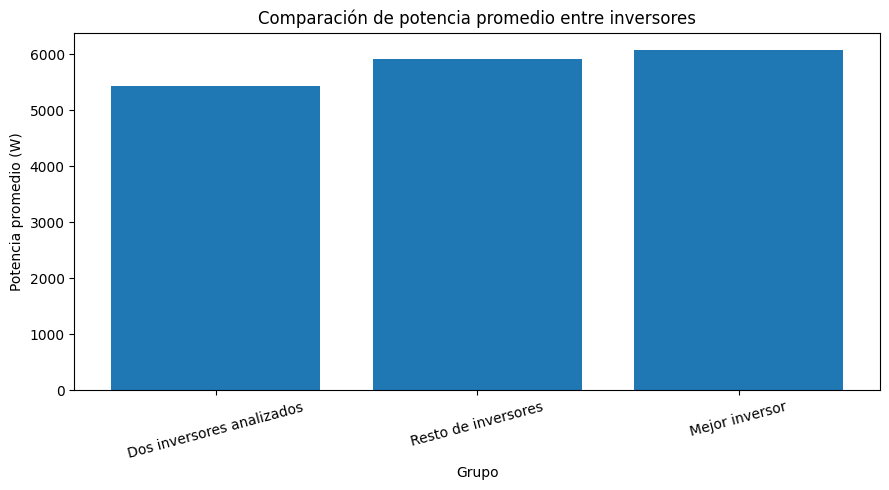

In [141]:
plt.figure(figsize = (9, 5))
plt.bar(comparison_power["Grupo"], comparison_power["Potencia_promedio"])
plt.title("Comparación de potencia promedio entre inversores")
plt.xlabel("Grupo")
plt.ylabel("Potencia promedio (W)")
plt.xticks(rotation = 15)
plt.tight_layout()
plt.show()

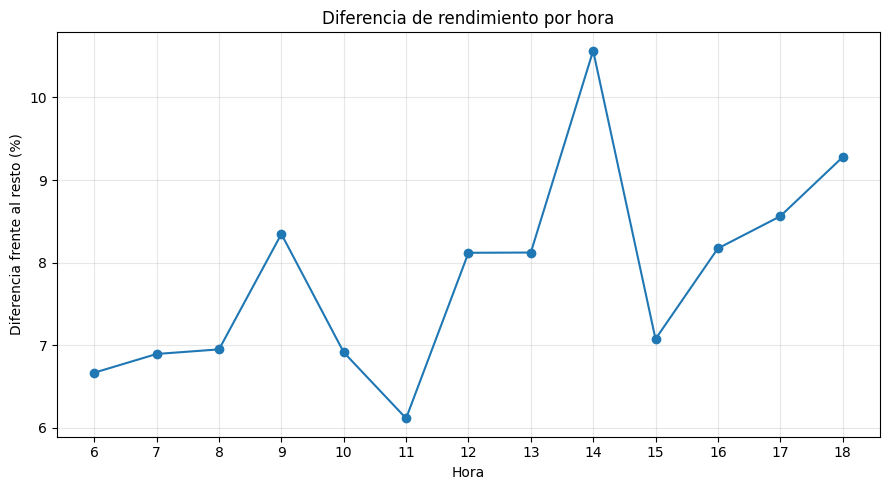

In [142]:
plt.figure(figsize = (9, 5))
plt.plot(hourly_comparison.index, hourly_comparison["difference_percentage"], marker = "o")
plt.title("Diferencia de rendimiento por hora")
plt.xlabel("Hora")
plt.ylabel("Diferencia frente al resto (%)")
plt.xticks(hourly_comparison.index)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones

La gráfica de barras muestra que los inversores `bvBOhCH3iADSZry` y `1BY6WEcLGh8j5v7` presentan una potencia promedio inferior al resto de los inversores. Su promedio conjunto fue de 5,424.97 W, frente a 5,922.96 W del resto y 6,077.34 W del mejor inversor.

La gráfica de línea muestra que esta diferencia no se concentra en una sola hora. Al excluir los registros con potencia cero, los dos inversores analizados mantienen un rendimiento inferior durante todas las horas productivas, con una diferencia que oscila entre 6.11% y 10.57% respecto al resto de los inversores.

En conjunto, ambas visualizaciones respaldan la existencia de un patrón consistente de menor desempeño en estos dos inversores.